# Sistema de Classificação de Risco para Concessão de Empréstimo

In [3]:
#Importação das Bibliotecas Essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [60]:
#Leitura do dataset armazenado na pasta onde está o código
dataset = pd.read_csv('risco.csv')

In [5]:
#Imprimir na tela os 10 primeiros registros com cabeçalho
dataset.head(10)

,id_cliente,anot_cadastrais,indice_inad,class_renda,saldo_contas,Risco
0,0,5.1,3.5,1.4,0.2,Risco_Alto
1,1,4.9,3.0,1.4,0.2,Risco_Alto
2,2,4.7,3.2,1.3,0.2,Risco_Alto
3,3,4.6,3.1,1.5,0.2,Risco_Alto
4,4,5.0,3.6,1.4,0.2,Risco_Alto
5,5,5.4,3.9,1.7,0.4,Risco_Alto
6,6,4.6,3.4,1.4,0.3,Risco_Alto
7,7,5.0,3.4,1.5,0.2,Risco_Alto
8,8,4.4,2.9,1.4,0.2,Risco_Alto
9,9,4.9,3.1,1.5,0.1,Risco_Alto


In [7]:
# Exibição de informações acerca do dataset (tipo das variáveis, quantidade de registros e variáveis,etc)
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_cliente       150 non-null    int64  
 1   anot_cadastrais  150 non-null    float64
 2   indice_inad      150 non-null    float64
 3   class_renda      150 non-null    float64
 4   saldo_contas     150 non-null    float64
 5   Risco            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [8]:
# Verificação das dimensões do dataset (linhas e colunas respectivamente)
dataset.shape

(150, 6)

In [9]:
# Estatísticas descritivas das variáveis numéricas (contagem, média, desvio padrão, valor máx, valor min, quartis)
dataset.describe()

,id_cliente,anot_cadastrais,indice_inad,class_renda,saldo_contas
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,74.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,0.000000,4.300000,2.000000,1.000000,0.100000
25%,37.250000,5.100000,2.800000,1.600000,0.300000
50%,74.500000,5.800000,3.000000,4.350000,1.300000
75%,111.750000,6.400000,3.300000,5.100000,1.800000
max,149.000000,7.900000,4.400000,6.900000,2.500000


In [10]:
# Tabela de frequência da variável "Risco", nossa Classe ou Label ou Target
dataset['Risco'].value_counts()

Risco_Alto     50
Risco_Medio    50
Risco_Baixo    50
Name: Risco, dtype: int64

In [11]:
# Outra forma de exibir a tabela de frequência
dataset.Risco.value_counts()

Risco_Alto     50
Risco_Medio    50
Risco_Baixo    50
Name: Risco, dtype: int64

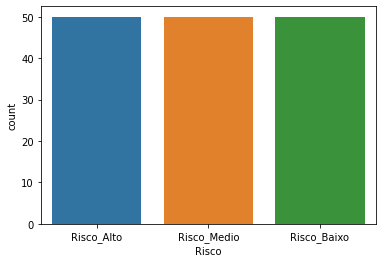

In [12]:
# Plotagem de gráfico de barras para a variável Risco (target)
sns.countplot(dataset['Risco'])

In [13]:
# Verificação de valores faltantes
dataset.isna().sum()

id_cliente         0
anot_cadastrais    0
indice_inad        0
class_renda        0
saldo_contas       0
Risco              0
dtype: int64

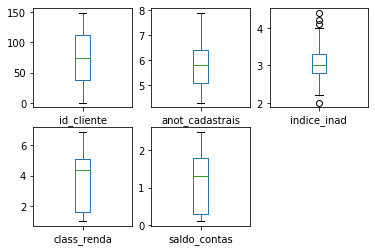

In [14]:
# Criação de um boxplot dos dados
from matplotlib import pyplot as plt #Já importada no início
dataset.plot(kind='box', subplots=True, layout=(2,3), sharex=False, sharey=False)
plt.show()

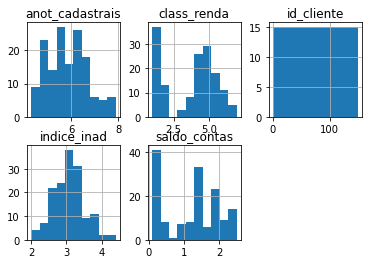

In [17]:
# Criação de um histograma dos dados (distribuição)
dataset.hist(layout=(2,3))
plt.show()

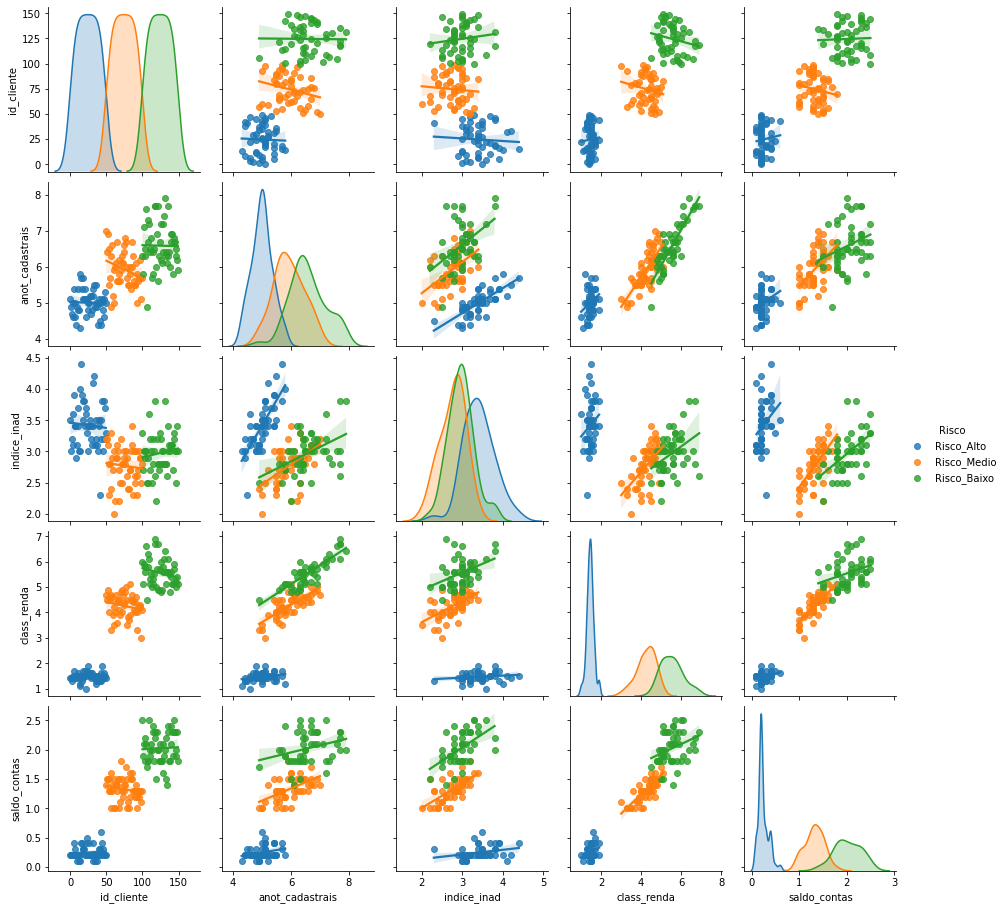

In [18]:
# Plotagem de Gráfico de Dispersão (scatter) conhecido como pairplot
sns.pairplot(dataset, hue='Risco', kind='reg') #kind=reg é a reta de regressão

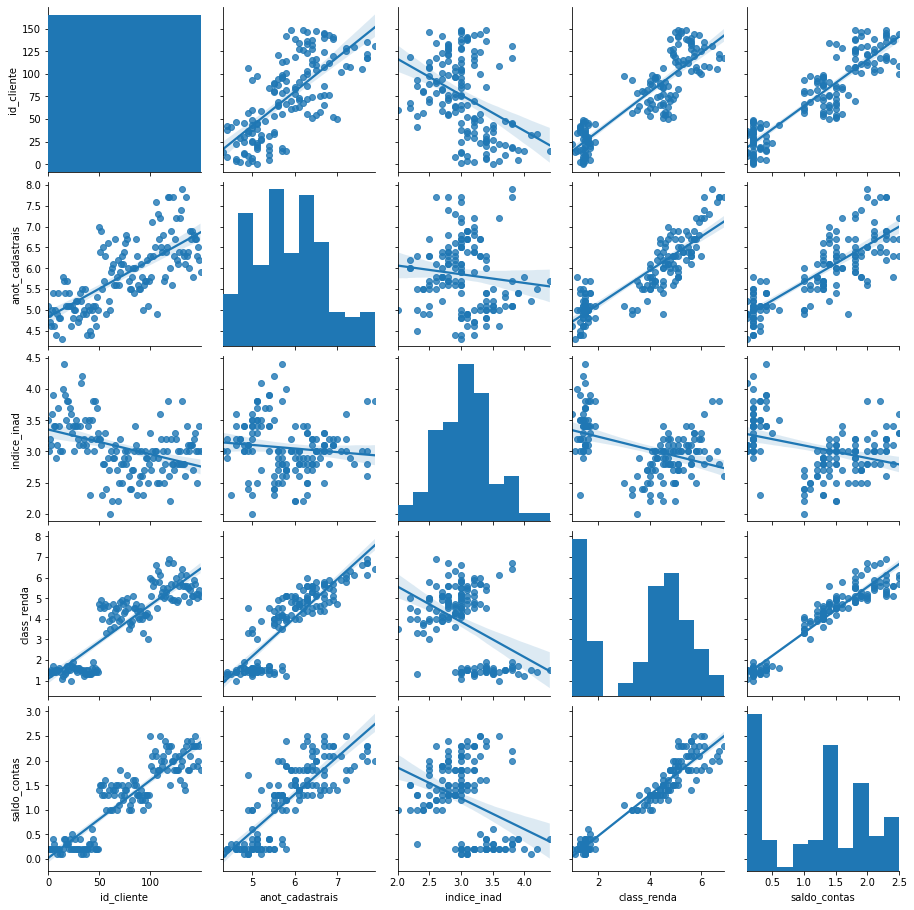

In [19]:
# Plotagem do Gráfico de Dispersão (scatter) sem agregar pelo Target
sns.pairplot(dataset, kind="reg") #kind=reg é a reta de regressão

In [20]:
dataset.head(10)

,id_cliente,anot_cadastrais,indice_inad,class_renda,saldo_contas,Risco
0,0,5.1,3.5,1.4,0.2,Risco_Alto
1,1,4.9,3.0,1.4,0.2,Risco_Alto
2,2,4.7,3.2,1.3,0.2,Risco_Alto
3,3,4.6,3.1,1.5,0.2,Risco_Alto
4,4,5.0,3.6,1.4,0.2,Risco_Alto
5,5,5.4,3.9,1.7,0.4,Risco_Alto
6,6,4.6,3.4,1.4,0.3,Risco_Alto
7,7,5.0,3.4,1.5,0.2,Risco_Alto
8,8,4.4,2.9,1.4,0.2,Risco_Alto
9,9,4.9,3.1,1.5,0.1,Risco_Alto


In [21]:
# Update do dataset eliminando a coluna 'id_cliente' pois ela não é variável explicativa
dataset = dataset.drop(columns='id_cliente')

In [22]:
dataset.head(10)

,anot_cadastrais,indice_inad,class_renda,saldo_contas,Risco
0,5.1,3.5,1.4,0.2,Risco_Alto
1,4.9,3.0,1.4,0.2,Risco_Alto
2,4.7,3.2,1.3,0.2,Risco_Alto
3,4.6,3.1,1.5,0.2,Risco_Alto
4,5.0,3.6,1.4,0.2,Risco_Alto
5,5.4,3.9,1.7,0.4,Risco_Alto
6,4.6,3.4,1.4,0.3,Risco_Alto
7,5.0,3.4,1.5,0.2,Risco_Alto
8,4.4,2.9,1.4,0.2,Risco_Alto
9,4.9,3.1,1.5,0.1,Risco_Alto


In [23]:
# Modelo de Machine Learning Supervisionado pois iremos utilizar dados do dataset para prever o comportamento no tempo futuro

In [24]:
# Separando as variáveis de Entrada e Saída do Modelo
X = dataset.iloc[:,:-1].values #Variáveis Independentes
Y = dataset.iloc[:,-1].values #Variável Dependente/Target/Label/Class

In [25]:
# Print das Variáveis X e Y
print("\nVariávies de Entrada da Avaliação: \n\n", X) #Utilização somente das 4 primeiras variáveis de entrada
print ("\nRisco - Variável a ser Predita: \n\n", Y)


Variávies de Entrada da Avaliação: 

 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4

In [26]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [27]:
Y[:5]

array(['Risco_Alto', 'Risco_Alto', 'Risco_Alto', 'Risco_Alto',
       'Risco_Alto'], dtype=object)

#### Separando os dados entre Treino e Teste

In [30]:
# Dividindo o dataset em Train and Test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7) #20% para teste e 80% para treino

In [37]:
# Exibição dos dados de Treino e Teste
print("Dados de Treino :\n-----------------\n")
print("X = \n", X_train) #Imprime os 5 primeiros
print("Y = \n", Y_train) #Imprime os 5 primeiros

print("\n\nDados de Teste : \n-----------------\n")
print("X = \n", X_test)
print("Y = \n", Y_test)

Dados de Treino :
-----------------

X = 
 [[6.2 2.8 4.8 1.8]
 [5.7 2.6 3.5 1. ]
 [4.6 3.6 1.  0.2]
 [6.9 3.1 5.4 2.1]
 [6.4 2.9 4.3 1.3]
 [4.8 3.  1.4 0.3]
 [5.5 3.5 1.3 0.2]
 [5.4 3.9 1.7 0.4]
 [5.1 3.5 1.4 0.3]
 [7.1 3.  5.9 2.1]
 [6.7 3.3 5.7 2.1]
 [6.8 2.8 4.8 1.4]
 [6.4 2.8 5.6 2.2]
 [6.5 3.  5.5 1.8]
 [5.7 3.  4.2 1.2]
 [5.  3.3 1.4 0.2]
 [6.7 3.1 4.4 1.4]
 [6.  2.2 4.  1. ]
 [6.4 2.7 5.3 1.9]
 [4.7 3.2 1.6 0.2]
 [4.6 3.1 1.5 0.2]
 [5.1 3.4 1.5 0.2]
 [7.7 3.8 6.7 2.2]
 [4.3 3.  1.1 0.1]
 [6.3 3.3 6.  2.5]
 [5.5 2.4 3.7 1. ]
 [5.  2.  3.5 1. ]
 [6.5 2.8 4.6 1.5]
 [5.  3.4 1.6 0.4]
 [4.4 2.9 1.4 0.2]
 [5.  3.5 1.6 0.6]
 [6.7 3.1 4.7 1.5]
 [7.3 2.9 6.3 1.8]
 [5.5 2.6 4.4 1.2]
 [5.2 2.7 3.9 1.4]
 [5.7 4.4 1.5 0.4]
 [7.2 3.2 6.  1.8]
 [5.4 3.4 1.7 0.2]
 [5.8 4.  1.2 0.2]
 [6.1 2.6 5.6 1.4]
 [5.7 2.5 5.  2. ]
 [4.8 3.  1.4 0.1]
 [6.5 3.  5.8 2.2]
 [4.6 3.2 1.4 0.2]
 [6.6 2.9 4.6 1.3]
 [6.7 3.  5.2 2.3]
 [6.1 3.  4.6 1.4]
 [5.7 3.8 1.7 0.3]
 [7.  3.2 4.7 1.4]
 [4.7 3.2 1.3 0.2]
 [6.5 3

In [38]:
# Contagem de dados utilizados para treino e para teste
print("Dados utilizados para treino: ", X_train.shape) #80% para treino com 4 variáveis explicativas
print("Dados utilizados para teste: ", X_test.shape) #20% para teste com 4 variáveis explicativas

Dados utilizados para treino:  (120, 4)
Dados utilizados para teste:  (30, 4)


#### Padronização das Variáveis Explicativas (Variáveis de Entrada)

In [40]:
# Redimensionamento dos Dados - Padronização - Feature Scaling
#StandardScaler é o método utilizado para padronizar os dados
#(deixa os dados com uma média igual a 0 e desvio padrão igual a 1)
from sklearn.preprocessing import StandardScaler 
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

print ("\n-----------------------------\nDataset após a Padronização:\n-----------------------------\n", )

print("\nX_train :\n", X_train)
print("-------------------------")
print("\nX_test :\n", X_test)


-----------------------------
Dataset após a Padronização:
-----------------------------


X_train :
 [[ 0.43325894 -0.59653573  0.62601116  0.82081788]
 [-0.15754871 -1.05688485 -0.09737951 -0.21464226]
 [-1.45732553  1.24486074 -1.48851543 -1.2501024 ]
 [ 1.26038965  0.09398794  0.95988378  1.20911544]
 [ 0.669582   -0.36636117  0.34778398  0.17365529]
 [-1.22100247 -0.13618661 -1.26593368 -1.12066988]
 [-0.39387177  1.01468618 -1.32157912 -1.2501024 ]
 [-0.51203329  1.93538441 -1.09899737 -0.99123737]
 [-0.86651788  1.01468618 -1.26593368 -1.12066988]
 [ 1.49671271 -0.13618661  1.23811096  1.20911544]
 [ 1.02406659  0.55433706  1.12682009  1.20911544]
 [ 1.14222812 -0.59653573  0.62601116  0.30308781]
 [ 0.669582   -0.59653573  1.07117465  1.33854796]
 [ 0.78774353 -0.13618661  1.01552922  0.82081788]
 [-0.15754871 -0.13618661  0.29213854  0.04422278]
 [-0.98467941  0.55433706 -1.26593368 -1.2501024 ]
 [ 1.02406659  0.09398794  0.40342942  0.30308781]
 [ 0.19693588 -1.97758308  0.1

#### Criando a Máquina Preditiva

In [42]:
# Importando da Biblioteca KNN
from sklearn.neighbors import KNeighborsClassifier
Maquina_Preditiva = KNeighborsClassifier(n_neighbors=30) #n_neighbors = k

In [43]:
# Treinamento da Máquina Preditiva com os dados de teste
Maquina_Preditiva = Maquina_Preditiva.fit(X_train, Y_train)

In [44]:
# Fazendo previsões com os dados de teste
Y_pred = Maquina_Preditiva.predict(X_test)

print("\n-------------------------\n")
print("Valores Reais com dados de teste: \n", Y_test)

print("\n-------------------------\n")
print("Valores Preditos com a Máquina Preditiva através dos dados de teste: \n", Y_pred)


-------------------------

Valores Reais com dados de teste: 
 ['Risco_Baixo' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio' 'Risco_Baixo'
 'Risco_Alto' 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio'
 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Baixo' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo' 'Risco_Alto' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo'
 'Risco_Baixo' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo']

-------------------------

Valores Preditos com a Máquina Preditiva através dos dados de teste: 
 ['Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio' 'Risco_Medio'
 'Risco_Alto' 'Risco_Baixo' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio'
 'Risco_Baixo' 'Risco_Medio' 'Risco_Alto' 'Risco_Baixo' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo' 'Risco_Alto' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo'
 'Risco_Medio' 'Risco_Medio' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo

In [45]:
# Uso da get_params que é a função que mostra os hyperparâmetros utilizados na construção da Máquina Preditiva

In [46]:
Maquina_Preditiva.get_params

<bound method BaseEstimator.get_params of KNeighborsClassifier(n_neighbors=30)>

In [47]:
# Cálculo da Acurácia (Razão entre o total de acertos e o total geral)
from sklearn import metrics
print ("Acurácioa da Máquina = ", metrics.accuracy_score(Y_test, Y_pred)*100)

Acurácioa da Máquina =  76.66666666666667


In [49]:
# Comparação entre os valores Real e Predito através dos dados de Teste
print("\nReal vs Predito \n---------------")
error_df = pd.DataFrame({"Real" : Y_test, "Predito" : Y_pred})
error_df.head(10)


Real vs Predito 
---------------


,Real,Predito
0,Risco_Baixo,Risco_Medio
1,Risco_Medio,Risco_Medio
2,Risco_Alto,Risco_Alto
3,Risco_Medio,Risco_Medio
4,Risco_Baixo,Risco_Medio
5,Risco_Alto,Risco_Alto
6,Risco_Medio,Risco_Baixo
7,Risco_Medio,Risco_Medio
8,Risco_Alto,Risco_Alto
9,Risco_Medio,Risco_Medio


In [50]:
# Aplicação da confusion matrix e o classification report para avaliar a acurácia e demais indicadores
from sklearn.metrics import confusion_matrix #Permite ver todos os erros e acertos do modelo 
from sklearn.metrics import classification_report #Traz mais algumas métrica para avaliar a previsão

In [51]:
print("Acurácia da Máquina = ", metrics.accuracy_score(Y_test, Y_pred)*100)
cm = confusion_matrix(Y_test, Y_pred) #A Diagonal representa todos os acertos do modelo
cr = classification_report(Y_test, Y_pred)
print(cm)
print(cr)

Acurácia da Máquina =  76.66666666666667
[[ 7  0  0]
 [ 0  6  5]
 [ 0  2 10]]
              precision    recall  f1-score   support

  Risco_Alto       1.00      1.00      1.00         7
 Risco_Baixo       0.75      0.55      0.63        11
 Risco_Medio       0.67      0.83      0.74        12

    accuracy                           0.77        30
   macro avg       0.81      0.79      0.79        30
weighted avg       0.78      0.77      0.76        30



#### Máquina Preditiva com Suport Vector Machine (SVC)

In [53]:
# Importação da biblioteca do SVM (Support Vectors Machine)
from sklearn.svm import SVC
classifier = SVC(kernel = 'linear',     # ['linear', rbf']
                 gamma = 1e-5,          # [1e-1, 1e-2, 1e-3, 1e-5]
                 C = 10,                # [10.0, 100.0, 1000.0, 10000.0]
                 random_state = 7)

In [54]:
# Treinamento da Máquina com o SVC
classifier.fit(X_train, Y_train)

# Fazendo novas previsões a partir dos dados de teste
Y_pred = classifier.predict(X_test)

In [55]:
print("Predicted Values for Test Set: \n", Y_pred)
print("\nActual Values for Test Set: \n", Y_test)

Predicted Values for Test Set: 
 ['Risco_Baixo' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio' 'Risco_Medio'
 'Risco_Alto' 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio'
 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Baixo' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo' 'Risco_Alto' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo'
 'Risco_Medio' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo']

Actual Values for Test Set: 
 ['Risco_Baixo' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio' 'Risco_Baixo'
 'Risco_Alto' 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Medio'
 'Risco_Medio' 'Risco_Medio' 'Risco_Alto' 'Risco_Baixo' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo' 'Risco_Alto' 'Risco_Alto'
 'Risco_Medio' 'Risco_Baixo' 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo'
 'Risco_Baixo' 'Risco_Medio' 'Risco_Medio' 'Risco_Baixo' 'Risco_Baixo']


In [56]:
classifier

SVC(C=10, gamma=1e-05, kernel='linear', random_state=7)

In [57]:
# Cálculo da Acurácia do modelo
from sklearn import metrics
print ("Acurácioa da Máquina = ", metrics.accuracy_score(Y_test, Y_pred)*100)

Acurácioa da Máquina =  90.0


In [58]:
# Comparação dos valores Real e Predito através dos dados de Teste Novamente
print("\nReal vs Predito \n---------------")
error_df = pd.DataFrame({"Real" : Y_test, "Predito" : Y_pred})
error_df.head(10)


Real vs Predito 
---------------


,Real,Predito
0,Risco_Baixo,Risco_Baixo
1,Risco_Medio,Risco_Medio
2,Risco_Alto,Risco_Alto
3,Risco_Medio,Risco_Medio
4,Risco_Baixo,Risco_Medio
5,Risco_Alto,Risco_Alto
6,Risco_Medio,Risco_Medio
7,Risco_Medio,Risco_Medio
8,Risco_Alto,Risco_Alto
9,Risco_Medio,Risco_Medio


In [59]:
print("Acurácia da Máquina = ", metrics.accuracy_score(Y_test, Y_pred)*100)
cm = confusion_matrix(Y_test, Y_pred) #A Diagonal representa todos os acertos do modelo
cr = classification_report(Y_test, Y_pred)
print(cm)
print(cr)

Acurácia da Máquina =  90.0
[[ 7  0  0]
 [ 0  8  3]
 [ 0  0 12]]
              precision    recall  f1-score   support

  Risco_Alto       1.00      1.00      1.00         7
 Risco_Baixo       1.00      0.73      0.84        11
 Risco_Medio       0.80      1.00      0.89        12

    accuracy                           0.90        30
   macro avg       0.93      0.91      0.91        30
weighted avg       0.92      0.90      0.90        30

